# Lab 00: Branch Selection & Energy-Based Objectives in Physics-Informed Learning

**Learning objective.** In physical systems with multi-valued equilibrium solutions (such as post-buckling or symmetric crack paths), understand why standard supervised regression converges to unphysical conditional averages, and how physics-informed energy minimization guides models toward valid physical branches.

**Predict first.** For equally likely targets $+\sqrt{s}$ and $-\sqrt{s}$ at the same control $s$, predict the best single squared-error prediction. Then examine the energy near $q=0$.

Follow the worked calculation, then use the downloadable notebook to explore the exercises.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CEMS-Lab/autumn-school/blob/main/notebooks/study/00_why_average_predictions_can_fail.ipynb)

[Download practice notebook](https://cems-lab.github.io/autumn-school/notebooks/study/00_why_average_predictions_can_fail.ipynb) · [Download with worked solutions](https://cems-lab.github.io/autumn-school/notebooks/solutions/00_why_average_predictions_can_fail.ipynb) · [Environment setup](https://cems-lab.github.io/autumn-school/SETUP.md) · [Read this lesson in the book](https://cems-lab.github.io/autumn-school/book/labs/00_why_average_predictions_can_fail.html)

Consider a scalar physical system governed by a double-well potential energy. For a control parameter $s \in [0.25, 1]$, define the potential energy:

$$
W(q; s) = \frac{(q^2 - s)^2}{4}.
$$

For any control value $s > 0$, the system admits two zero-energy equilibrium states:

$$
q_+(s) = +\sqrt{s} \quad \text{and} \quad q_-(s) = -\sqrt{s}.
$$

In this tutorial, we contrast two learning paradigms:
1. **Supervised Regression (Mean Squared Error):** Trained on balanced observations from both branches.
2. **Physics-Informed Energy Minimization:** Guided directly by the potential energy functional with a positive branch parameterisation ($q = \operatorname{softplus}(a) > 0$).

In [1]:
# Environment setup is measured separately from the classroom computation.
from pathlib import Path
import importlib.metadata
import json
import os
import subprocess
import sys
import time

setup_started = time.perf_counter()
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not (3, 10) <= sys.version_info[:2] < (3, 13):
    raise RuntimeError("This PhAST snapshot supports Python 3.10–3.12. Select a compatible runtime; see Environment Setup.")

def locate_course_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        for candidate in (base, base / "autumn-school", base / "teaching/ukacm_autumn_school_2026"):
            if (candidate / "notebooks/day2_helpers").is_dir() and (candidate / "vendor/PhAST/src").is_dir():
                return candidate.resolve()
    return None

COURSE_ROOT = locate_course_root()
if COURSE_ROOT is None and IN_COLAB:
    COURSE_ROOT = Path.cwd() / "autumn-school"
    if COURSE_ROOT.exists():
        raise RuntimeError("An incomplete autumn-school folder exists. Start a fresh runtime or select the complete course folder.")
    # A release tag or full commit can be supplied for a fixed course edition.
    course_ref = os.environ.get("PHAST_COURSE_REF", "main")
    subprocess.run(["git", "init", str(COURSE_ROOT)], check=True, capture_output=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "remote", "add", "origin", "https://github.com/CEMS-Lab/autumn-school.git"], check=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "fetch", "--depth", "1", "origin", course_ref], check=True, timeout=180)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "checkout", "--detach", "FETCH_HEAD"], check=True, capture_output=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Open the notebook from the complete course folder, including notebooks/, configs/ and vendor/. See Environment Setup.")

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", str(COURSE_ROOT / "vendor/PhAST"), "nbformat", "nbclient", "nbconvert"], check=True, timeout=600)

for package_dir in (COURSE_ROOT / "vendor/PhAST/src", COURSE_ROOT / "notebooks"):
    if str(package_dir) not in sys.path:
        sys.path.insert(0, str(package_dir))

revision = subprocess.run(["git", "-C", str(COURSE_ROOT), "rev-parse", "HEAD"], text=True, capture_output=True)
package_versions = {}
for package in ("torch", "numpy", "scipy", "matplotlib", "nbformat"):
    try:
        package_versions[package] = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        package_versions[package] = "install using Environment Setup"
setup_receipt = {
    "environment": "Google Colab" if IN_COLAB else "local",
    "python": sys.version.split()[0],
    "course_revision": revision.stdout.strip() if revision.returncode == 0 else "downloaded archive",
    "versions": package_versions,
    "setup_seconds": round(time.perf_counter() - setup_started, 3),
}
print(setup_receipt)

import matplotlib.pyplot as plt
import numpy as np
import torch
from io import BytesIO
from IPython.display import Image, display
from day2_helpers import assets_dir

torch.set_default_dtype(torch.float64)
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    "figure.titlesize": 13, "figure.dpi": 150, "axes.grid": True,
    "grid.alpha": 0.3, "grid.linestyle": "--", "lines.linewidth": 1.8,
})

def display_figure(figure, dpi=150, alt="Rendered teaching figure"):
    """Retain figures for reading in the book and in a fresh notebook session."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), alt=alt))

import platform
from torch import nn
from torch.nn import functional as F
torch.manual_seed(20260909)
torch.set_num_threads(1)
# Preserve the original model-initialisation convention; calculations use float64.
torch.set_default_dtype(torch.float32)
dtype = torch.float64
ASSETS = COURSE_ROOT / "assets/teaser"
ASSETS.mkdir(parents=True, exist_ok=True)


{'environment': 'local', 'python': '3.10.18', 'course_revision': '077d43d87c55b4fdea720808fc24f040e957e1ea', 'versions': {'torch': '2.8.0', 'numpy': '2.2.6', 'scipy': '1.14.1', 'matplotlib': '3.10.8', 'nbformat': '5.10.4'}, 'setup_seconds': 0.025}


## Balanced supervision versus an energy objective

The training inputs are repeated so that every $s$ has one positive and
one negative target.  Under squared error, the best single deterministic
prediction is their conditional mean, $0$.  That point is between the
two reference branches and has nonzero residual $q^2-s=-s$.

In [2]:
s_unique = torch.linspace(0.25, 1.00, 96, dtype=dtype).unsqueeze(1)
branch_positive = torch.sqrt(s_unique)
branch_negative = -branch_positive
s_supervised = s_unique.repeat_interleave(2, dim=0)
q_supervised_target = torch.stack(
    (branch_positive.squeeze(1), branch_negative.squeeze(1)), dim=1
).reshape(-1, 1)
s_heldout = torch.linspace(0.255, 0.995, 73, dtype=dtype).unsqueeze(1)

def residual(q, s):
    return q.square() - s

def energy(q, s):
    return residual(q, s).square() / 4.0

class TinyScalarMLP(nn.Module):
    def __init__(self, positive_branch=False):
        super().__init__()
        self.hidden = nn.Sequential(
            nn.Linear(1, 16),
            nn.Tanh(),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
        )
        self.positive_branch = positive_branch

    def forward(self, s):
        raw = self.hidden(s)
        return F.softplus(raw) + 1.0e-8 if self.positive_branch else raw

print({
    "unique_s_train": int(s_unique.shape[0]),
    "balanced_supervised_pairs": int(s_supervised.shape[0]),
    "heldout_s": int(s_heldout.shape[0]),
    "reference_branches_per_s": 2,
})

{'unique_s_train': 96, 'balanced_supervised_pairs': 192, 'heldout_s': 73, 'reference_branches_per_s': 2}


In [3]:
torch.manual_seed(20260909)
supervised_model = TinyScalarMLP().to(dtype=dtype)
supervised_optimiser = torch.optim.Adam(supervised_model.parameters(), lr=2.0e-2)
supervised_start = time.perf_counter()
for _ in range(800):
    supervised_optimiser.zero_grad(set_to_none=True)
    supervised_loss = torch.mean(
        (supervised_model(s_supervised) - q_supervised_target).square()
    )
    supervised_loss.backward()
    supervised_optimiser.step()
supervised_seconds = time.perf_counter() - supervised_start

torch.manual_seed(20260910)
positive_model = TinyScalarMLP(positive_branch=True).to(dtype=dtype)
positive_optimiser = torch.optim.Adam(positive_model.parameters(), lr=2.0e-2)
positive_start = time.perf_counter()
for _ in range(1000):
    positive_optimiser.zero_grad(set_to_none=True)
    positive_loss = energy(positive_model(s_unique), s_unique).mean()
    positive_loss.backward()
    positive_optimiser.step()
positive_seconds = time.perf_counter() - positive_start

print({
    "supervised_mse_on_balanced_targets": float(supervised_loss.detach()),
    "energy_loss_positive_branch": float(positive_loss.detach()),
    "supervised_training_seconds": round(supervised_seconds, 4),
    "positive_branch_training_seconds": round(positive_seconds, 4),
})

{'supervised_mse_on_balanced_targets': 0.6250000049495941, 'energy_loss_positive_branch': 1.6824936103105914e-06, 'supervised_training_seconds': 0.2075, 'positive_branch_training_seconds': 0.226}


## Stationary points and reference branches

The energy derivative is

$$
\frac{\partial W}{\partial q}=q(q^2-s).
$$

Thus $q=0$ has zero energy gradient, a residual of $-s$ and
positive energy when $s>0$.  The next cell evaluates that fact
directly.  The energy model starts on the positive branch through its softplus
output. This explicit branch selection determines which solution it learns.

In [4]:
s_stationary = torch.tensor(0.64, dtype=dtype)
q_stationary = torch.tensor(0.0, dtype=dtype, requires_grad=True)
W_stationary = energy(q_stationary, s_stationary)
(grad_stationary,) = torch.autograd.grad(W_stationary, q_stationary)
r_stationary = residual(q_stationary.detach(), s_stationary)
print({
    "s": float(s_stationary),
    "W_at_q0": float(W_stationary.detach()),
    "residual_at_q0": float(r_stationary),
    "dW_dq_at_q0": float(grad_stationary),
})
assert abs(float(grad_stationary)) < 1.0e-15
assert abs(float(r_stationary)) > 0.1

{'s': 0.64, 'W_at_q0': 0.1024, 'residual_at_q0': -0.64, 'dW_dq_at_q0': -0.0}


In [5]:
with torch.no_grad():
    q_supervised = supervised_model(s_heldout)
    q_positive = positive_model(s_heldout)
    r_supervised = residual(q_supervised, s_heldout)
    r_positive = residual(q_positive, s_heldout)
    W_supervised = energy(q_supervised, s_heldout)
    W_positive = energy(q_positive, s_heldout)
    metrics = {
        "heldout_count": int(s_heldout.shape[0]),
        "supervised_max_abs_prediction": float(q_supervised.abs().max()),
        "supervised_mean_abs_residual": float(r_supervised.abs().mean()),
        "supervised_mean_energy": float(W_supervised.mean()),
        "positive_min_prediction": float(q_positive.min()),
        "positive_mean_abs_residual": float(r_positive.abs().mean()),
        "positive_max_abs_residual": float(r_positive.abs().max()),
        "positive_mean_energy": float(W_positive.mean()),
        "positive_branch_rmse": float(
            torch.sqrt(torch.mean((q_positive - torch.sqrt(s_heldout)).square()))
        ),
    }

assert metrics["supervised_max_abs_prediction"] < 0.03
assert metrics["supervised_mean_abs_residual"] > 0.50
assert metrics["positive_min_prediction"] > 0.0
assert metrics["positive_mean_abs_residual"] < 0.02
assert metrics["positive_mean_energy"] < metrics["supervised_mean_energy"]
print(metrics)
(ASSETS / "teaser_metrics.json").write_text(
    json.dumps(metrics, indent=2), encoding="utf-8"
)

{'heldout_count': 73, 'supervised_max_abs_prediction': 0.0001623609215912064, 'supervised_mean_abs_residual': 0.6249999952779399, 'supervised_mean_energy': 0.10938147994308955, 'positive_min_prediction': 0.5136183526070731, 'positive_mean_abs_residual': 0.002002033038503439, 'positive_max_abs_residual': 0.00880381213480369, 'positive_mean_energy': 1.5331257738901223e-06, 'positive_branch_rmse': 0.001987931297689105}


439

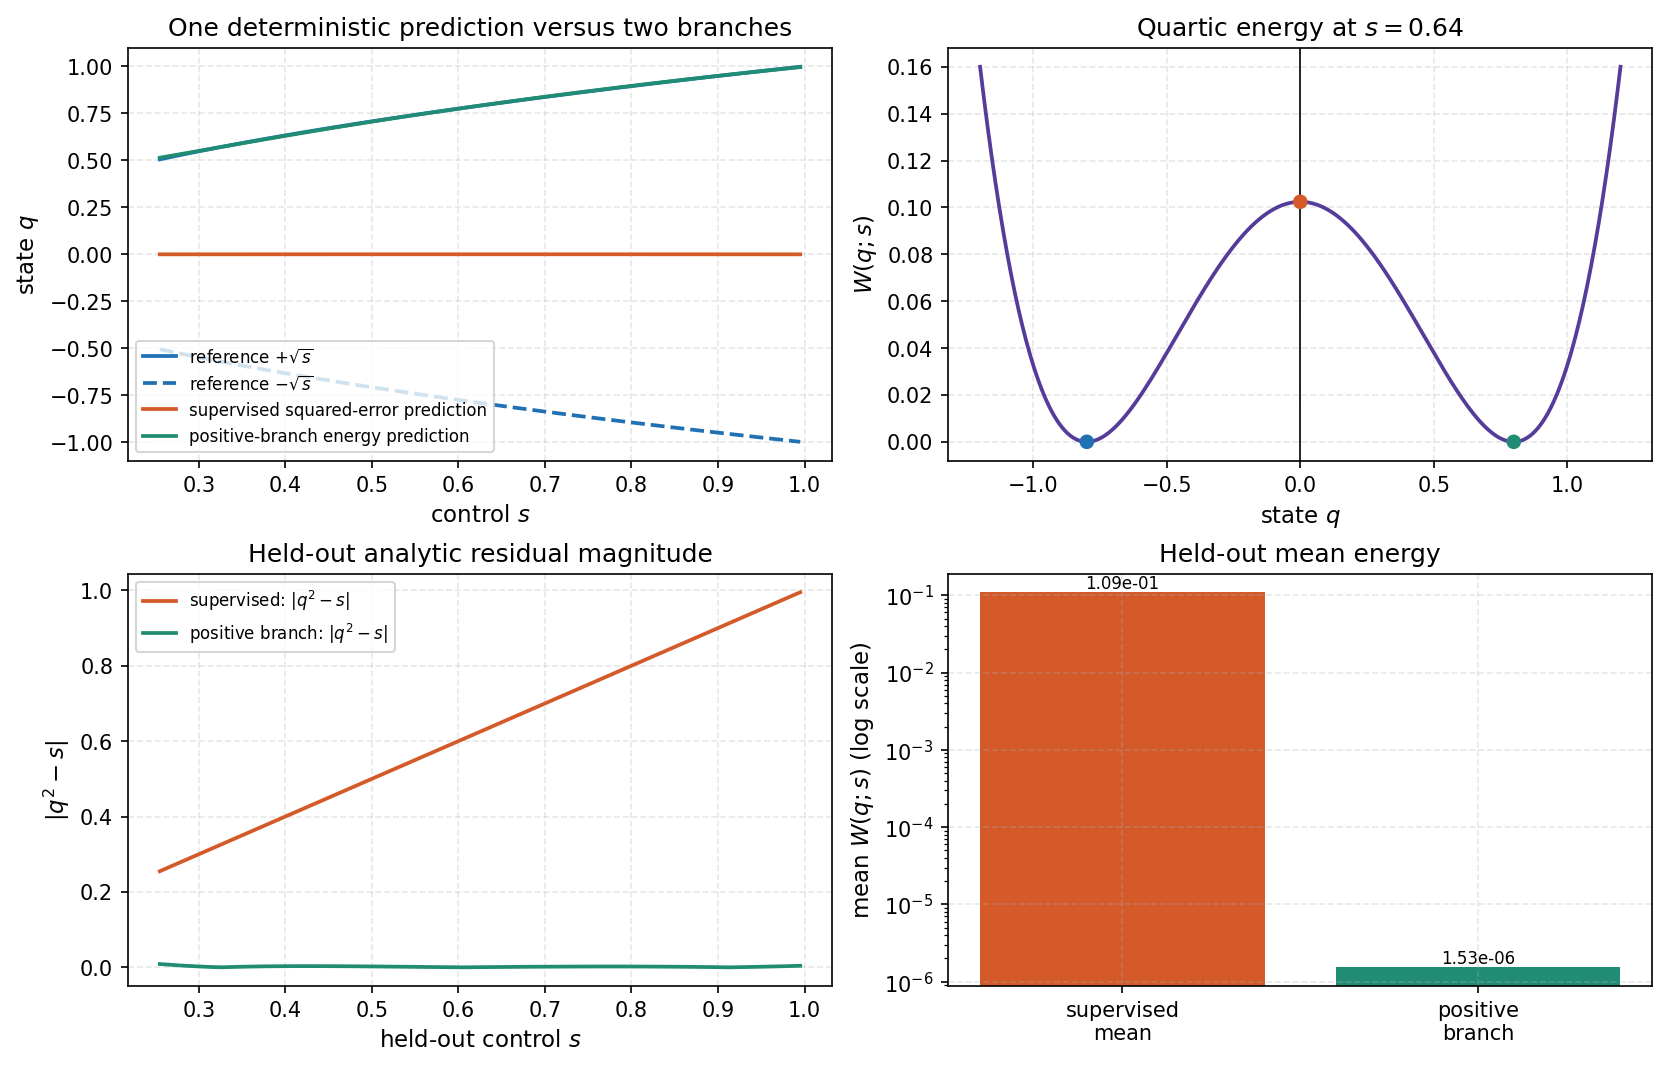

{'figure': 'assets/teaser/why_average_predictions_can_fail.png', 'metrics': {'heldout_count': 73, 'supervised_max_abs_prediction': 0.0001623609215912064, 'supervised_mean_abs_residual': 0.6249999952779399, 'supervised_mean_energy': 0.10938147994308955, 'positive_min_prediction': 0.5136183526070731, 'positive_mean_abs_residual': 0.002002033038503439, 'positive_max_abs_residual': 0.00880381213480369, 'positive_mean_energy': 1.5331257738901223e-06, 'positive_branch_rmse': 0.001987931297689105}}


In [6]:
s_plot = s_heldout.squeeze(1).cpu().numpy()
q_sup_plot = q_supervised.squeeze(1).cpu().numpy()
q_pos_plot = q_positive.squeeze(1).cpu().numpy()
r_sup_plot = r_supervised.abs().squeeze(1).cpu().numpy()
r_pos_plot = r_positive.abs().squeeze(1).cpu().numpy()
s_energy = torch.tensor(0.64, dtype=dtype)
q_axis = torch.linspace(-1.2, 1.2, 500, dtype=dtype)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
axes[0, 0].plot(s_plot, torch.sqrt(s_heldout).squeeze(1).cpu().numpy(),
                color="#2070b4", label=r"reference $+\sqrt{s}$")
axes[0, 0].plot(s_plot, -torch.sqrt(s_heldout).squeeze(1).cpu().numpy(),
                color="#2070b4", linestyle="--", label=r"reference $-\sqrt{s}$")
axes[0, 0].plot(s_plot, q_sup_plot, color="#d45a2a",
                label="supervised squared-error prediction")
axes[0, 0].plot(s_plot, q_pos_plot, color="#218c74",
                label="positive-branch energy prediction")
axes[0, 0].set(title="One deterministic prediction versus two branches",
               xlabel=r"control $s$", ylabel=r"state $q$")
axes[0, 0].legend(fontsize=8, loc="best")

axes[0, 1].plot(q_axis.cpu().numpy(), energy(q_axis, s_energy).cpu().numpy(),
                color="#553c9a")
axes[0, 1].scatter([0.0, float(torch.sqrt(s_energy)), -float(torch.sqrt(s_energy))],
                   [float(energy(torch.tensor(0.0, dtype=dtype), s_energy)),
                    0.0, 0.0],
                   color=["#d45a2a", "#218c74", "#2070b4"], zorder=3)
axes[0, 1].axvline(0.0, color="black", linewidth=0.8)
axes[0, 1].set(title=r"Quartic energy at $s=0.64$",
               xlabel=r"state $q$", ylabel=r"$W(q;s)$")

axes[1, 0].plot(s_plot, r_sup_plot, color="#d45a2a",
                label="supervised: $|q^2-s|$")
axes[1, 0].plot(s_plot, r_pos_plot, color="#218c74",
                label="positive branch: $|q^2-s|$")
axes[1, 0].set(title="Held-out analytic residual magnitude",
               xlabel=r"held-out control $s$", ylabel=r"$|q^2-s|$")
axes[1, 0].legend(fontsize=8)

names = ["supervised\nmean", "positive\nbranch"]
axes[1, 1].bar(names, [metrics["supervised_mean_energy"], metrics["positive_mean_energy"]],
               color=["#d45a2a", "#218c74"])
axes[1, 1].set_yscale("log")
axes[1, 1].set(title="Held-out mean energy",
               ylabel=r"mean $W(q;s)$ (log scale)")
for index, value in enumerate(
    [metrics["supervised_mean_energy"], metrics["positive_mean_energy"]]
):
    axes[1, 1].text(index, value, f"{value:.2e}", ha="center", va="bottom", fontsize=8)

figure_path = ASSETS / "why_average_predictions_can_fail.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print({"figure": str(figure_path.relative_to(COURSE_ROOT)), "metrics": metrics})

## Physical interpretation

The two objectives answer different questions about the same training inputs.

- **Balanced supervision.** Squared-error regression estimates the conditional mean, $\mathbb{E}[q\mid s]=0$. At this prediction the algebraic residual is $r=-s$ and the reduced energy is $W(0;s)=s^2/4$. The reference branches satisfy $q=\pm\sqrt{s}$ and have zero residual and energy.
- **A selected energy branch.** The output $q=\operatorname{softplus}(a)$ is positive. Minimising $W(q;s)$ within this parameterisation guides the model towards the positive reference branch. Inspect the held-out residual and energy curves to assess the trained approximation.

This reduced algebraic model illustrates how the objective and output representation shape a prediction. For a fracture application, connect that choice to the observed branch, the fracture energy and the admissibility constraints of the mechanical model.


## Key takeaways

- Balanced squared-error regression estimates the conditional mean of the training targets.
- For the reduced energy $W(q;s)=(q^2-s)^2/4$, the equilibria $q=\pm\sqrt{s}$ form two branches.
- The output parameterisation supplies a branch preference; the energy describes the relation each branch satisfies.
- Held-out field predictions, residuals and energy provide complementary views of a learned approximation.

## Exercises

Try each question before opening the hint or worked solution. Keep the original calculation as your reference.

### Exercise 1: Conditional Mean vs. Physical Branch Minimization

At a fixed control parameter $s>0$, let $a=\sqrt{s}$. Suppose the training data contain equally balanced observations from both branches, $+a$ and $-a$.

1. Prove analytically that the mean-squared error loss is minimised uniquely at $q=0$.
2. For $s=0.64$, evaluate the residual $r=q^2-s$, the energy $W=(q^2-s)^2/4$, and the energy gradient $\partial W/\partial q$ at $q=0$.
3. Explain why gradient-based optimisation needs a symmetry-breaking choice to move away from the stationary point at $q=0$.

### Exercise 2: Explore the branches and the meaning of the objective

1. Sketch $W(q;s)$ for two positive values of $s$. How do the positions of its minima change?
2. In a new cell, evaluate the residual and energy on a grid of $q$ values for your chosen $s$, then plot both. Mark the supervised mean and the two reference branches.
3. Explain how a positive output parameterisation affects the predictions. Suggest an output representation for observations occupying both branches.